# YC Startups Analysis
**Dataset:** 5,690 Y Combinator companies

**Goals:** Market research + job hunting

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

conn = sqlite3.connect("../data/yc_collaboration.db")
df = pd.read_sql("SELECT * FROM companies", conn)
conn.close()

print(f"Total companies: {len(df)}")
df.head()

## 1. Overview Stats

In [8]:
print("=== Company Status ===")
print(df["status"].value_counts())
print(f"\n=== Hiring ===")
print(f"Currently hiring: {df['is_hiring'].sum()} ({df['is_hiring'].mean()*100:.1f}%)")
print(f"\n=== Team Size ===")
print(df["team_size"].describe())
print(f"\n=== Stage ===")
print(df["stage"].value_counts())

=== Company Status ===
status
Active      3930
Inactive    1005
Acquired     732
Public        23
Name: count, dtype: int64

=== Hiring ===
Currently hiring: 1432 (25.2%)

=== Team Size ===
count    5590.000000
mean       48.120215
std       301.581844
min         0.000000
25%         2.000000
50%         6.000000
75%        20.000000
max      8600.000000
Name: team_size, dtype: float64

=== Stage ===
stage
Early     4652
Growth    1038
Name: count, dtype: int64


## 2. Companies by Batch (Timeline)

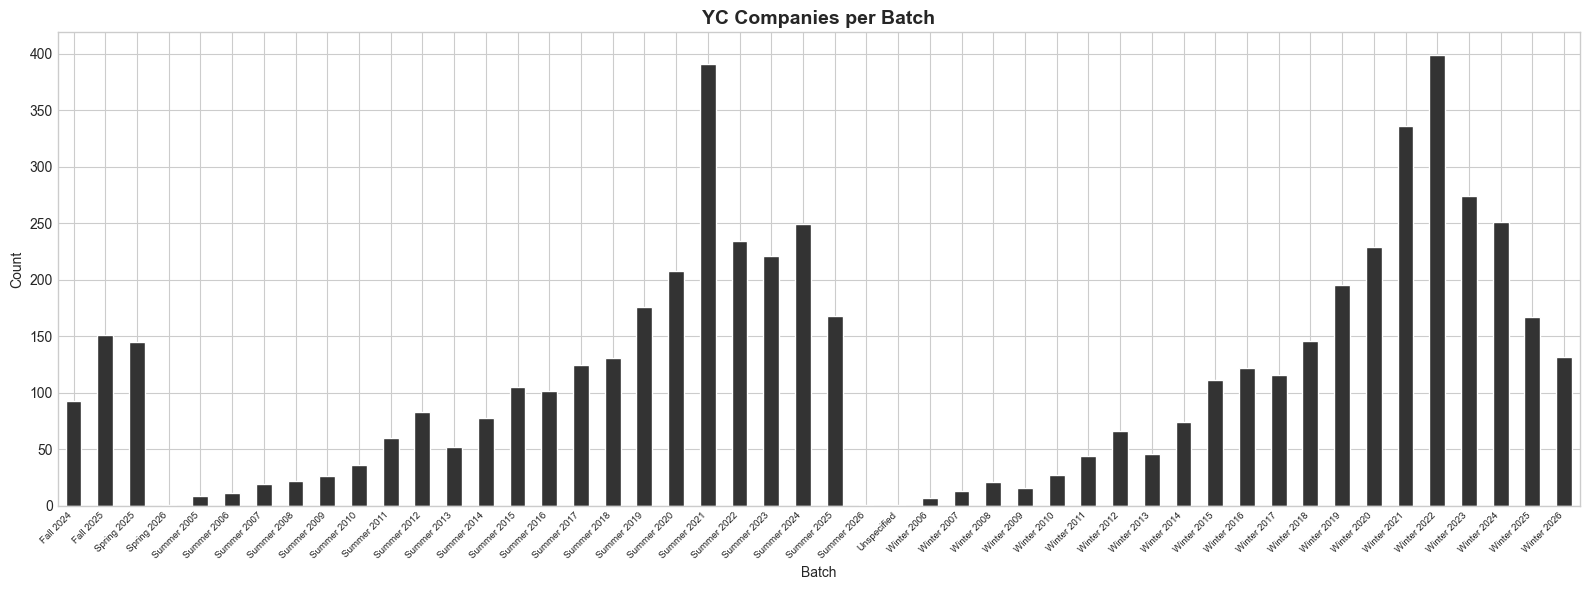

In [9]:
batch_counts = df["batch"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
batch_counts.plot(kind="bar", ax=ax, color="#333333", edgecolor="white")
ax.set_title("YC Companies per Batch", fontsize=14, fontweight="bold")
ax.set_xlabel("Batch")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## 3. Top Industries

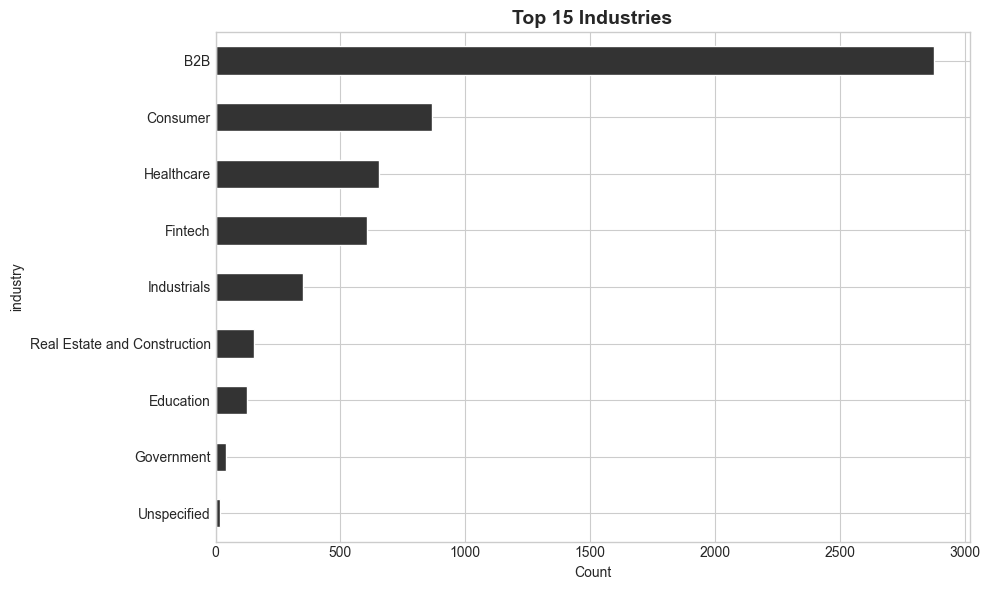

In [10]:
industry_counts = df["industry"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
industry_counts.plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 15 Industries", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Active vs Inactive by Industry

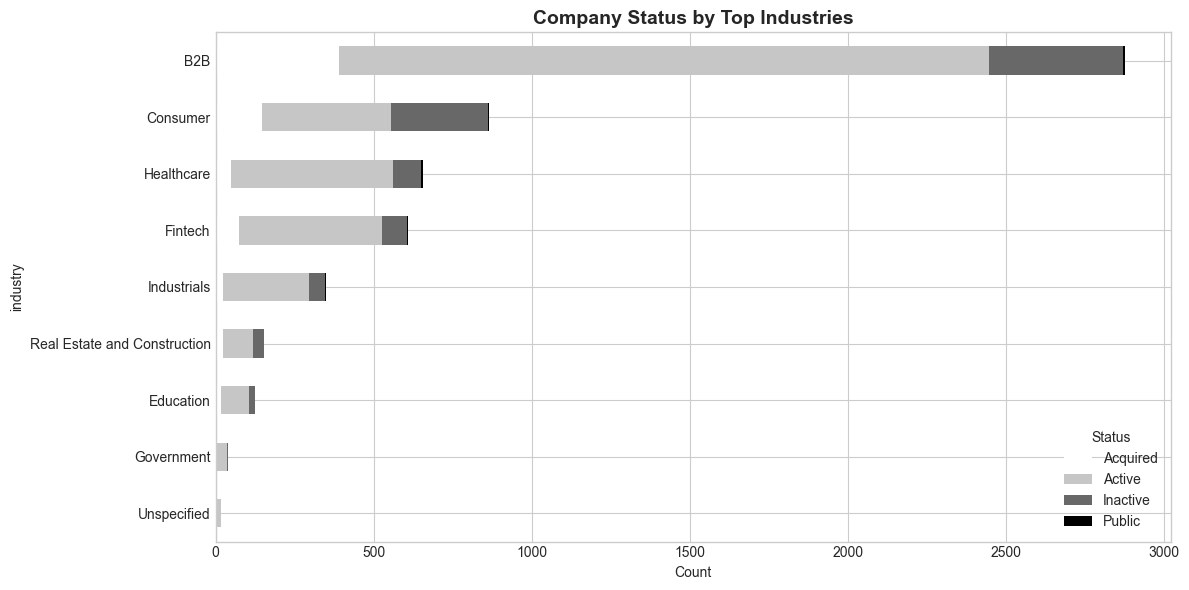

In [11]:
top_industries = df["industry"].value_counts().head(10).index
subset = df[df["industry"].isin(top_industries)]

status_by_industry = subset.groupby(["industry", "status"]).size().unstack(fill_value=0)
status_by_industry = status_by_industry.loc[top_industries]  # preserve order

fig, ax = plt.subplots(figsize=(12, 6))
status_by_industry.plot(kind="barh", stacked=True, ax=ax, colormap="Greys")
ax.set_title("Company Status by Top Industries", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
ax.legend(title="Status")
plt.tight_layout()
plt.show()

## 5. Geography - Top Locations

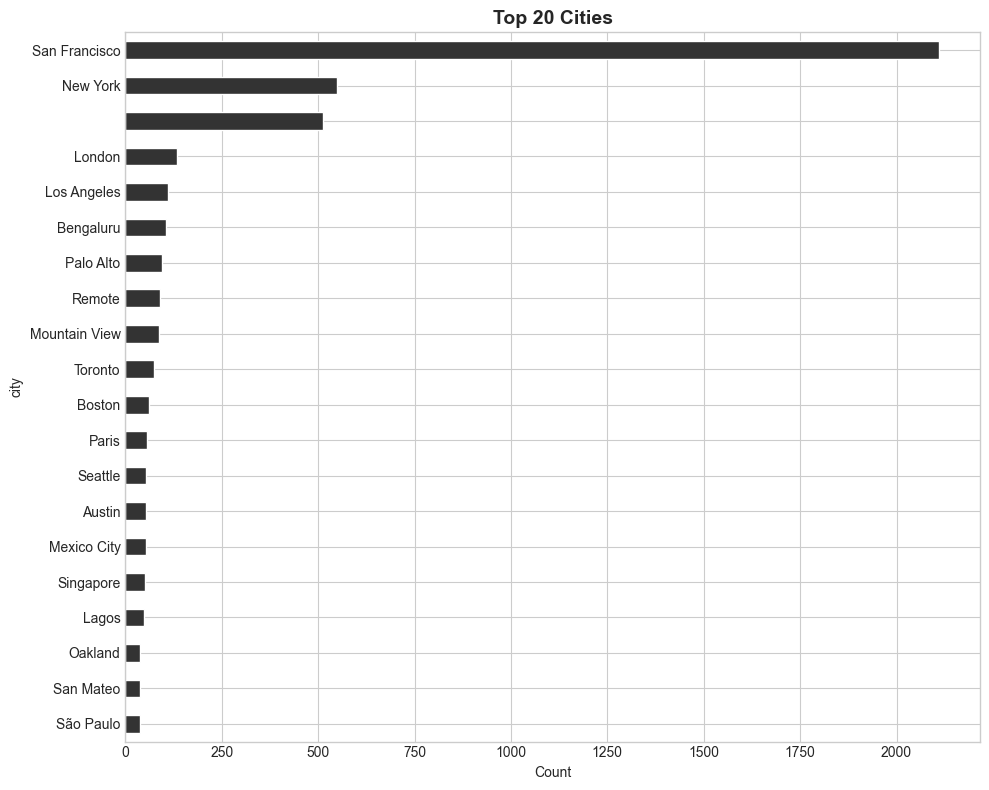

In [12]:
# Extract city from location (first part before comma)
df["city"] = df["location"].str.split(",").str[0].str.strip()

city_counts = df["city"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
city_counts.plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Cities", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Team Size Distribution

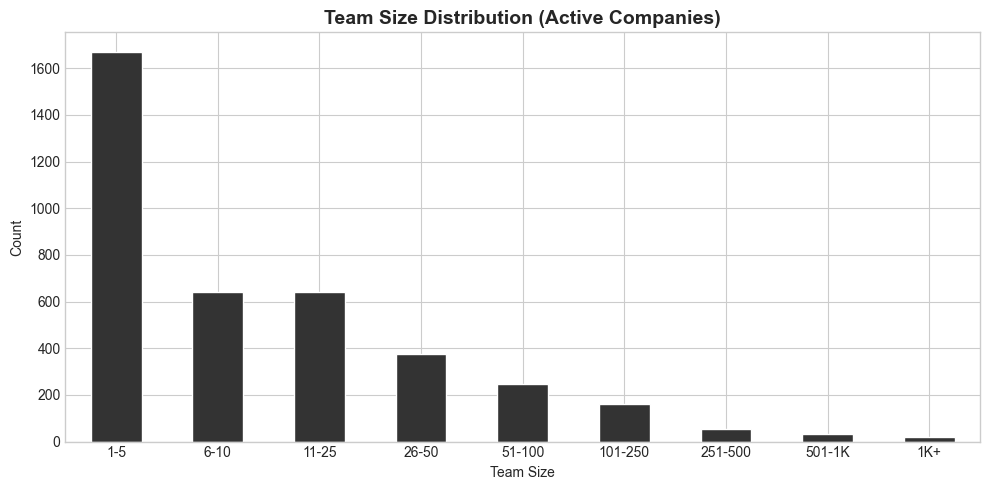

In [13]:
active = df[df["status"] == "Active"]

bins = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 50000]
labels = ["1-5", "6-10", "11-25", "26-50", "51-100", "101-250", "251-500", "501-1K", "1K+"]
active = active.copy()
active["size_bucket"] = pd.cut(active["team_size"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(10, 5))
active["size_bucket"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Team Size Distribution (Active Companies)", fontsize=14, fontweight="bold")
ax.set_xlabel("Team Size")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Survival Rate by Batch Year

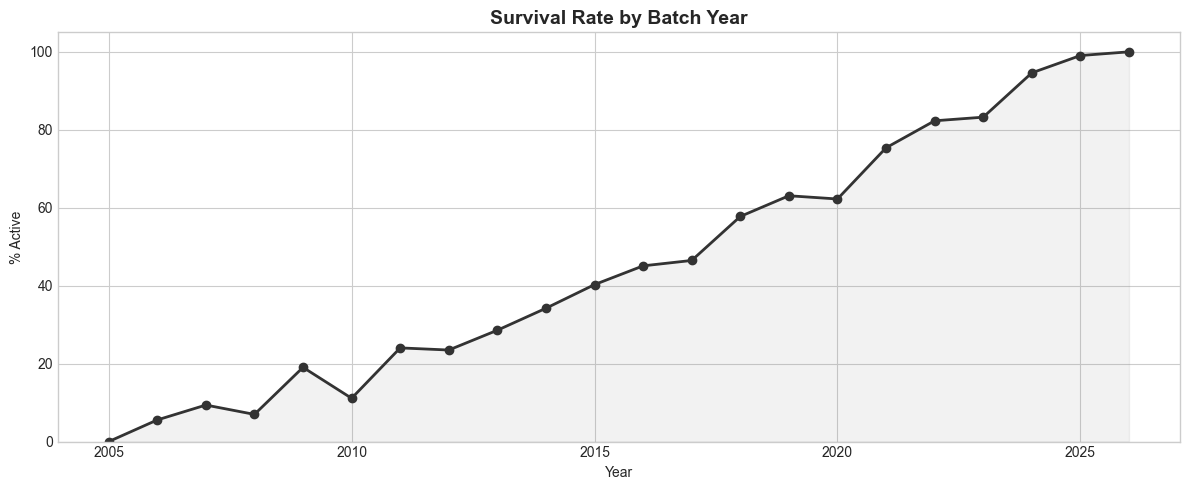

In [14]:
# Extract year from batch (e.g. "Winter 2012" -> 2012)
df["batch_year"] = df["batch"].str.extract(r"(\d{4})").astype(float)

survival = df.groupby("batch_year").apply(
    lambda g: (g["status"] == "Active").mean() * 100
).reset_index(name="survival_rate")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(survival["batch_year"], survival["survival_rate"], marker="o", color="#333333", linewidth=2)
ax.fill_between(survival["batch_year"], survival["survival_rate"], alpha=0.1, color="gray")
ax.set_title("Survival Rate by Batch Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% Active")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 8. Most Common Tags (What's Hot)

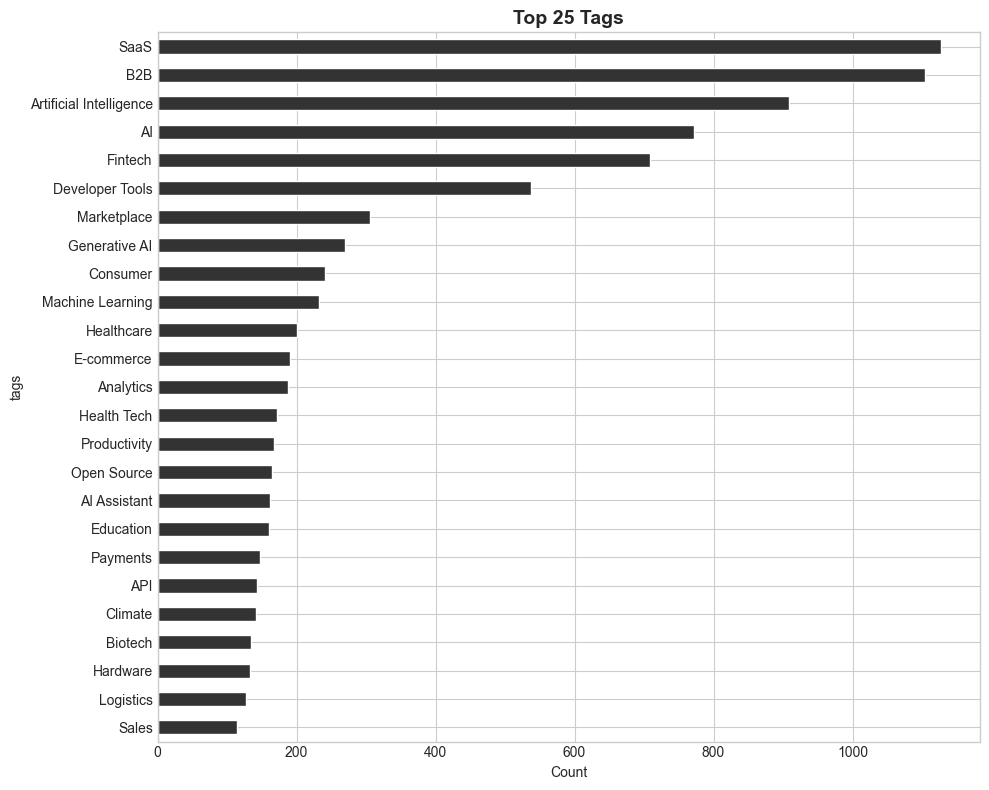

In [15]:
# Explode semicolon-separated tags
all_tags = df["tags"].str.split("; ").explode().str.strip()
all_tags = all_tags[all_tags != ""]

tag_counts = all_tags.value_counts().head(25)

fig, ax = plt.subplots(figsize=(10, 8))
tag_counts.plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 25 Tags", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Job Hunting - Hiring Companies

In [16]:
hiring = df[(df["is_hiring"] == 1) & (df["status"] == "Active")].copy()
hiring = hiring.sort_values("team_size", ascending=False)

print(f"Active & Hiring: {len(hiring)} companies\n")

# Top hiring by industry
print("=== Hiring by Industry ===")
print(hiring["industry"].value_counts().head(10))

print(f"\n=== Top 20 Largest Hiring Companies ===")
hiring[["name", "one_liner", "website", "team_size", "location", "batch"]].head(20)

Active & Hiring: 1423 companies

=== Hiring by Industry ===
industry
B2B                             821
Fintech                         161
Healthcare                      161
Consumer                        118
Industrials                      93
Real Estate and Construction     34
Education                        20
Government                       14
Unspecified                       1
Name: count, dtype: int64

=== Top 20 Largest Hiring Companies ===


,name,one_liner,website,team_size,location,batch
229,Stripe,Economic infrastructure for the internet.,http://stripe.com,7000.0,"San Francisco, CA, USA",Summer 2009
2261,99minutos,The fastest shipping for online shopping,https://99minutos.com,5000.0,"Mexico City, CDMX, Mexico; Santiago, Santiago ...",Winter 2020
1773,Deel,The all-in-one HR and payroll platform for glo...,https://www.deel.com/,5000.0,"San Francisco, CA, USA; Remote",Winter 2019
1039,Rappi,On-demand delivery and financial services for ...,http://www.rappi.com,4800.0,"Bogotá, Bogota, Colombia",Winter 2016
575,Flexport,Platform for global logistics.,https://www.flexport.com/careers/jobs/,3000.0,"San Francisco, CA, USA",Winter 2014
785,Razorpay,India's only full-stack financial solutions co...,https://razorpay.com,2700.0,"Bengaluru, KA, India",Winter 2015
1160,Rippling,"One place to run all your HR, IT, and Finance....",http://rippling.com/,2500.0,"San Francisco, CA, USA",Winter 2017
19,Gusto,Provides growing businesses with everything to...,https://gusto.com,2400.0,"San Francisco, CA, USA",Winter 2012
1108,Athelas,"Extensible, Integrated Technology that Simplif...",http://athelas.com,1000.0,"Mountain View, CA, USA",Summer 2016
1020,Relativity Space,Building humanity’s multiplanetary future.,http://relativityspace.com,1000.0,"Los Angeles, CA, USA; Seattle, WA, USA; Washin...",Winter 2016


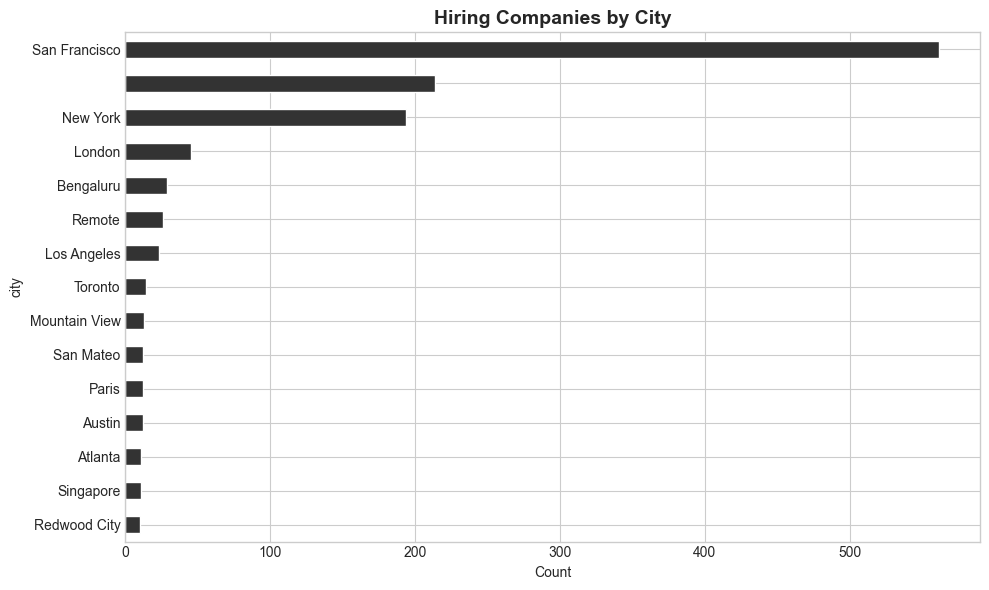

In [17]:
# Hiring companies by location
hiring["city"] = hiring["location"].str.split(",").str[0].str.strip()

fig, ax = plt.subplots(figsize=(10, 6))
hiring["city"].value_counts().head(15).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Hiring Companies by City", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Search & Filter Tool

In [18]:
def search(keyword=None, industry=None, hiring_only=False, status="Active", min_team=0, max_team=100000):
    """Filter companies by multiple criteria."""
    result = df.copy()
    if status:
        result = result[result["status"] == status]
    if hiring_only:
        result = result[result["is_hiring"] == 1]
    if industry:
        result = result[result["industry"].str.contains(industry, case=False, na=False)]
    if keyword:
        mask = (
            result["name"].str.contains(keyword, case=False, na=False)
            | result["one_liner"].str.contains(keyword, case=False, na=False)
            | result["tags"].str.contains(keyword, case=False, na=False)
        )
        result = result[mask]
    result = result[(result["team_size"] >= min_team) & (result["team_size"] <= max_team)]
    return result[["name", "one_liner", "website", "team_size", "is_hiring", "location", "batch", "tags"]]

# Examples:
# search(keyword="AI", hiring_only=True)
# search(industry="B2B", min_team=10, max_team=100)
# search(keyword="python", hiring_only=True)

search(keyword="AI", hiring_only=True).head(20)

,name,one_liner,website,team_size,is_hiring,location,batch,tags
75,Streak,Streak transforms Gmail into a powerful CRM,http://streak.com,35.0,1,Remote,Summer 2011,SaaS
259,Volantio,Post-booking revenue and capacity optimization...,http://www.volantio.com,19.0,1,"Atlanta, GA, USA",Winter 2009,Airlines
395,Zentail,We're making ecommerce simple connecting brand...,https://zentail.com,30.0,1,"Columbia, MD, USA",Summer 2012,SaaS; E-commerce
534,Lob,Lob is the only automation platform that trans...,http://lob.com,150.0,1,"San Francisco, CA, USA",Summer 2013,Automation
566,Noora Health,Training patients and their families with heal...,http://noorahealth.org,500.0,1,"Bengaluru, KA, India",Winter 2014,Consumer Health Services
575,Flexport,Platform for global logistics.,https://www.flexport.com/careers/jobs/,3000.0,1,"San Francisco, CA, USA",Winter 2014,SaaS; Logistics; Supply Chain
684,Hive,Marketing automation for event promoters (emai...,http://www.hive.co,65.0,1,"Kitchener, ON, Canada; Remote",Summer 2014,SaaS; CRM; SMS; Email
750,Tempo,Live home fitness training powered by computer...,https://tempo.fit/,158.0,1,"San Francisco, CA, USA",Winter 2015,Machine Learning; Consumer Health Services
812,Mashgin,Self-Checkout using Computer Vision.,http://mashgin.com,75.0,1,"Palo Alto, CA, USA",Winter 2015,Cashierless Checkout; Deep Learning; Hardware;...
832,SnapMagic,AI copilot for electronics design,https://www.snapmagic.com,32.0,1,"San Francisco, CA, USA",Summer 2015,Developer Tools; Hardware; Marketplace; AI
